In [11]:
import numpy as np
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split

In [12]:
# Load preprocessed data
X = np.load("savedPackages/padded_sequences.npy")
y = np.load("savedPackages/labels.npy")
with open("savedPackages/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)


In [13]:
# Parameters
vocab_size = 10000
max_len = 100
embedding_dim = 100  # GloVe 100d

In [14]:
embedding_index = {}
with open("embeddings/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

In [15]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))
word_index = tokenizer.word_index

for word, i in word_index.items():
    if i < vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True,         # Freeze embeddings
        mask_zero=True
    ),
    Bidirectional(LSTM(64, recurrent_dropout=0.2, kernel_regularizer=l2(0.01))),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

D:\SentimentAnalyzer_Project\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.1, patience=2)
]

In [20]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 1069s 1s/step - accuracy: 0.8329 - loss: 1.2579 - val_accuracy: 0.9501 - val_loss: 0.2082 - learning_rate: 0.0010
Epoch 2/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 1126s 1s/step - accuracy: 0.9524 - loss: 0.2025 - val_accuracy: 0.9577 - val_loss: 0.1683 - learning_rate: 0.0010
Epoch 3/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 1069s 1s/step - accuracy: 0.9581 - loss: 0.1701 - val_accuracy: 0.9597 - val_loss: 0.1568 - learning_rate: 0.0010
Epoch 4/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 1037s 1s/step - accuracy: 0.9611 - loss: 0.1555 - val_accuracy: 0.9595 - val_loss: 0.1544 - learning_rate: 0.0010
Epoch 5/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 891s 1s/step - accuracy: 0.9623 - loss: 0.1467 - val_accuracy: 0.9562 - val_loss: 0.1545 - learning_rate: 0.0010
Epoch 6/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 887s 1s/step - accuracy: 0.9633 - loss: 0.1431 - val_accuracy: 0.9597 - val_loss: 0.1495 - learning_rate: 0.0010
Epoch 7/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 893s 1s/step - accuracy: 0.9646 - loss

In [21]:
model.save("sentiment_model_lstm_glove_true2.keras")
with open("tokenizer_for_lstm_glove_true.pkl", "wb") as f:
    pickle.dump(tokenizer, f)



In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def preprocess_text(text, tokenizer, max_len=100):
    # Convert text to sequence of integers
    sequence = tokenizer.texts_to_sequences([text])
    # Pad the sequence
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    return padded

In [24]:
def predict_sentiment(text, model, tokenizer):
    padded_sequence = preprocess_text(text, tokenizer)
    prediction = model.predict(padded_sequence)
    predicted_class = prediction.argmax(axis=1)[0]

    label_map = {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    }

    return label_map[predicted_class], prediction[0]


In [27]:
text_input = "I should not kill anyone!"
sentiment, probabilities = predict_sentiment(text_input, model, tokenizer)

print(f"Predicted Sentiment: {sentiment}")
print(f"Class Probabilities: {probabilities}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Predicted Sentiment: Negative
Class Probabilities: [9.9985087e-01 1.0643335e-04 4.2679178e-05]


In [22]:
sequence = tokenizer.texts_to_sequences(["I am really happy with the service. It was amazing!"])
print(sequence)


[[10, 118, 114, 23, 16, 2, 561, 21, 49, 60]]


In [29]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)  # assuming softmax output


3282/3282 ━━━━━━━━━━━━━━━━━━━━ 128s 38ms/step


In [30]:
print("✅ Accuracy:", accuracy_score(y_test, y_pred))

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


✅ Accuracy: 0.9613238095238095

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.96      0.96     35000
     Neutral       0.97      0.96      0.96     35000
    Positive       0.95      0.97      0.96     35000

    accuracy                           0.96    105000
   macro avg       0.96      0.96      0.96    105000
weighted avg       0.96      0.96      0.96    105000



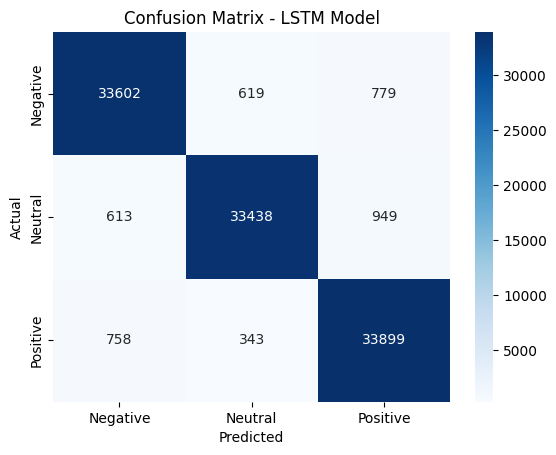

In [31]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LSTM Model")
plt.show()


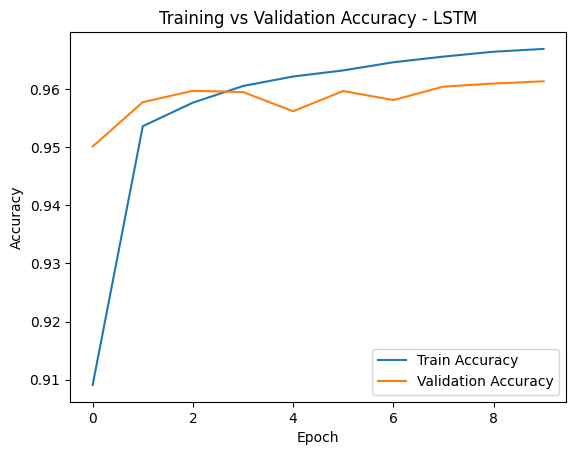

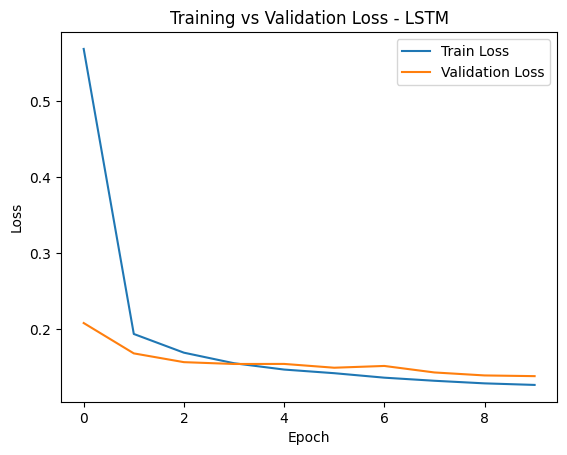

In [32]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy - LSTM")
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - LSTM")
plt.legend()
plt.show()


In [33]:
# Save test data
np.save("X_test_for_lstm.npy", X_test)
np.save("y_test_for_lstm.npy", y_test)

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Macro Precision:", precision_score(y_test, y_pred, average='macro'))
print("Macro Recall:", recall_score(y_test, y_pred, average='macro'))
print("Macro F1-Score:", f1_score(y_test, y_pred, average='macro'))

print("Micro Precision:", precision_score(y_test, y_pred, average='micro'))
print("Micro Recall:", recall_score(y_test, y_pred, average='micro'))
print("Micro F1-Score:", f1_score(y_test, y_pred, average='micro'))


Macro Precision: 0.9614435578843518
Macro Recall: 0.9613238095238096
Macro F1-Score: 0.9613344048555472
Micro Precision: 0.9613238095238095
Micro Recall: 0.9613238095238095
Micro F1-Score: 0.9613238095238095


In [35]:
for i, label in enumerate(['Negative', 'Neutral', 'Positive']):
    class_indices = np.where(y_test == i)[0]
    class_accuracy = accuracy_score(y_test[class_indices], y_pred[class_indices])
    print(f"{label} Accuracy: {class_accuracy:.4f}")


Negative Accuracy: 0.9601
Neutral Accuracy: 0.9554
Positive Accuracy: 0.9685


In [36]:
from sklearn.metrics import roc_auc_score

# One-hot encode y_test
from tensorflow.keras.utils import to_categorical
y_test_oh = to_categorical(y_test, num_classes=3)

roc_auc = roc_auc_score(y_test_oh, y_pred_probs, multi_class='ovr')
print("ROC AUC Score:", roc_auc)


ROC AUC Score: 0.9954143889115646


In [37]:
# Find incorrect predictions
wrong_indices = np.where(y_pred != y_test)[0]
print("Some Wrong Predictions:")
for i in wrong_indices[:5]:
    print("Text:", original_texts[i])  # Only if you saved texts
    print("Actual:", ['Negative', 'Neutral', 'Positive'][y_test[i]])
    print("Predicted:", ['Negative', 'Neutral', 'Positive'][y_pred[i]])
    print()


Some Wrong Predictions:


NameError: name 'original_texts' is not defined

In [38]:
with open("lstm_evaluation_report.txt", "w") as f:
    f.write("Accuracy: " + str(accuracy_score(y_test, y_pred)) + "\n\n")
    f.write(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


In [39]:
import os

print("Model Size (MB):", os.path.getsize("lstm_model.keras") / 1024**2)


FileNotFoundError: [WinError 2] The system cannot find the file specified: 'lstm_model.keras'

In [9]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("sentiment_model_lstm_glove_true2.keras")

# Print full architecture summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,278,795 (12.51 MB)

 Trainable params: 1,092,931 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,185,864 (8.34 MB)

In [5]:
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("sentiment_model_lstm_glove_true2.keras")

# Save the model architecture diagram
plot_model(model, to_file="lstm_model_architecture.png", show_shapes=True, show_layer_names=True)


You must install pydot (`pip install pydot`) for `plot_model` to work.


In [4]:
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
import io

# Load the model
model = load_model("sentiment_model_lstm_glove_true2.keras")

# Capture summary in a string
stream = io.StringIO()
model.summary(print_fn=lambda x: stream.write(x + '\n'))
summary_str = stream.getvalue()
stream.close()

# Plot as text in matplotlib
plt.figure(figsize=(10, 10))
plt.axis('off')
plt.text(0, 1, summary_str, fontsize=10, fontfamily='monospace', verticalalignment='top')
plt.savefig("lstm_model_summary_text.png", bbox_inches='tight')
plt.close()


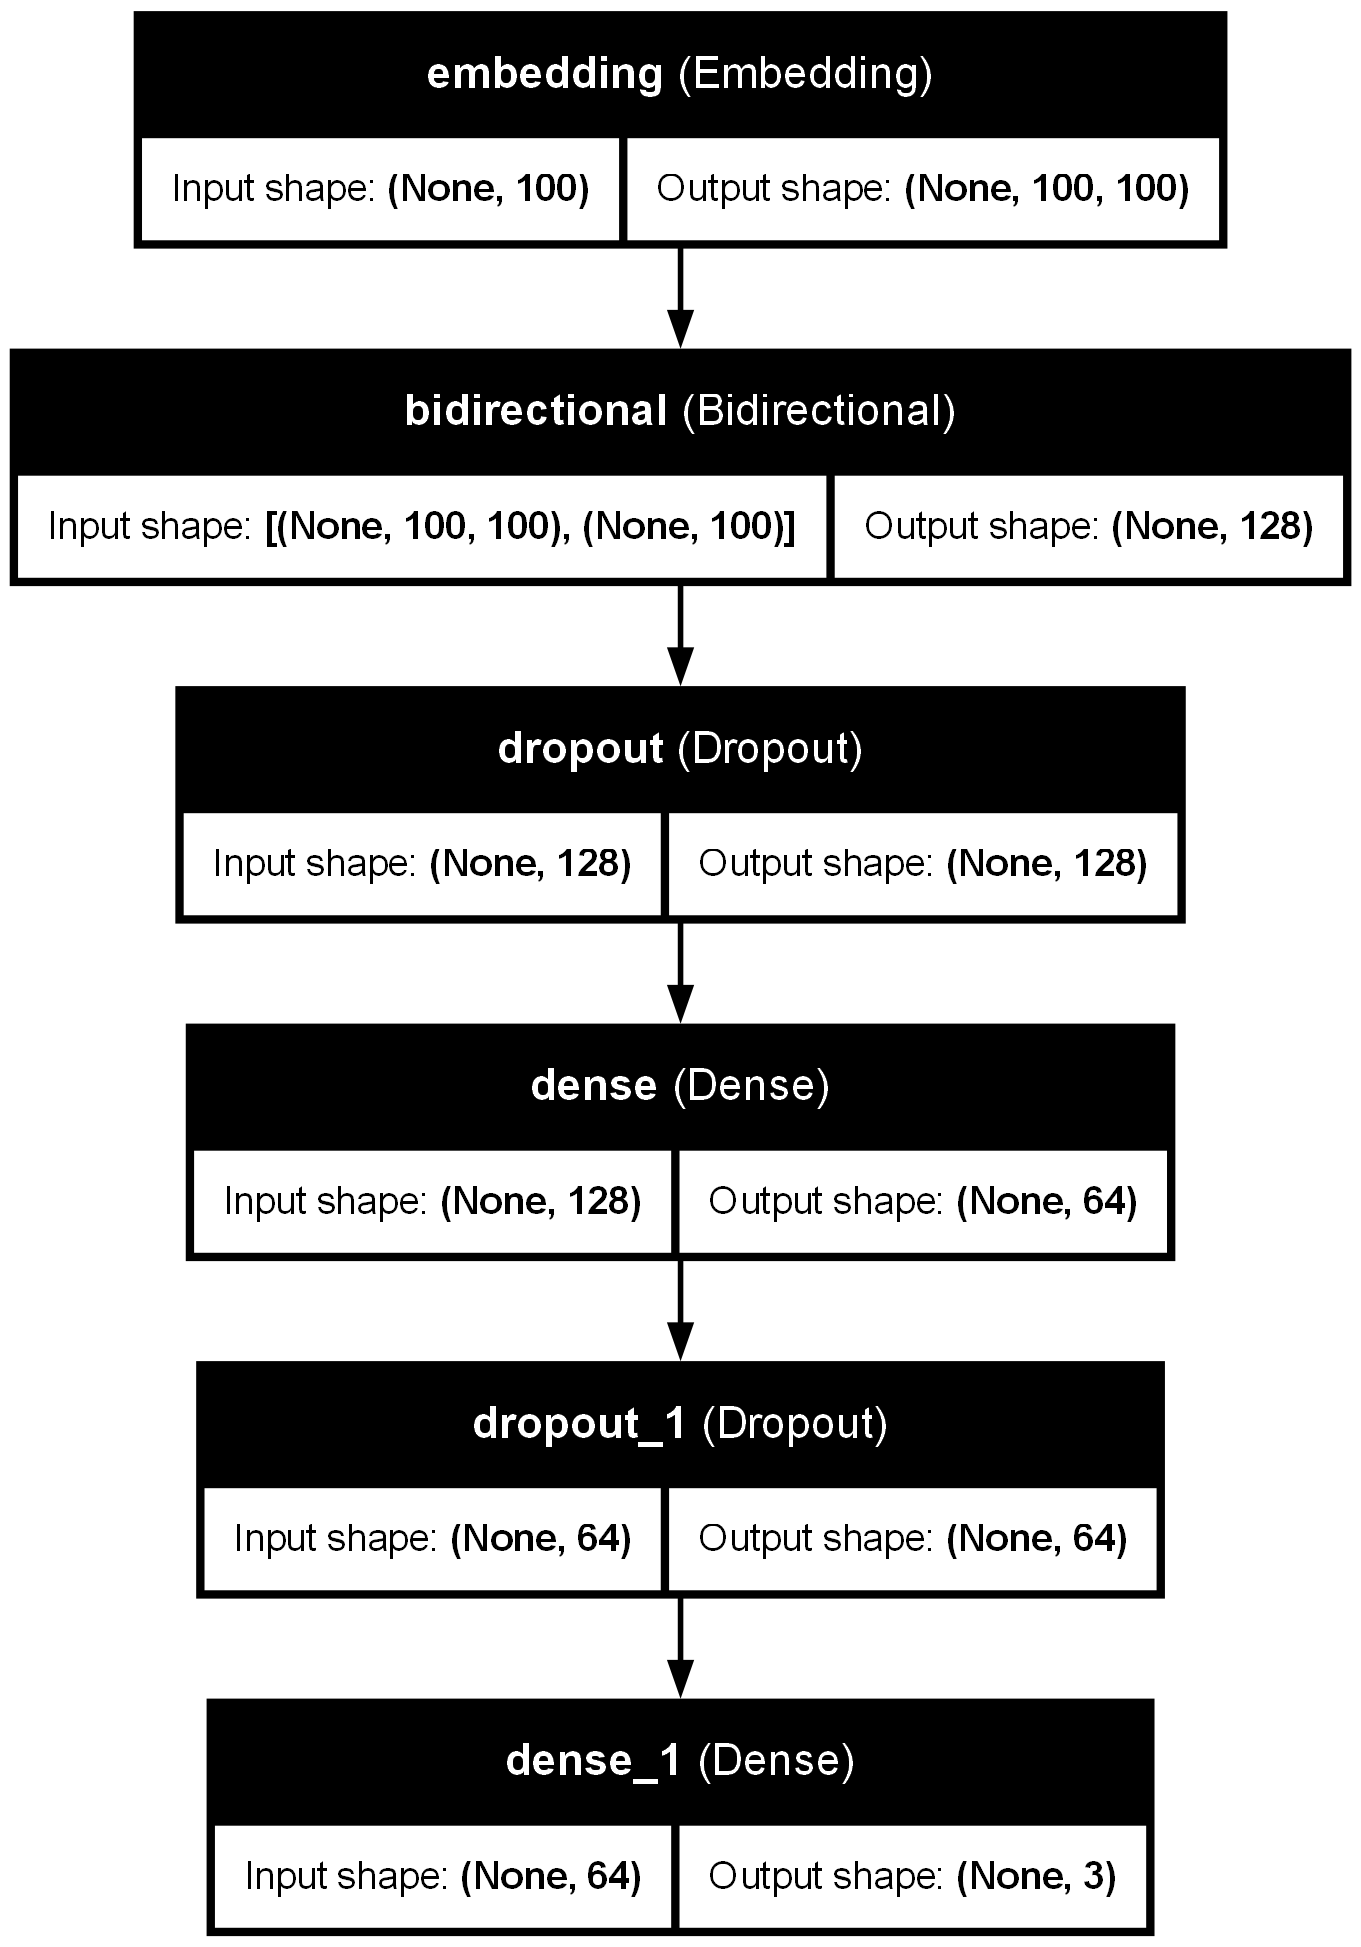

In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

# Load the saved model
model = load_model("sentiment_model_lstm_glove_true2.keras")

# Print full architecture summary
plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

In [2]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("sentiment_model_lstm_glove_true2.keras")

# Print full architecture summary
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,278,795 (12.51 MB)

 Trainable params: 1,092,931 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,185,864 (8.34 MB)